In [1]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time

import scipy.sparse as sps
import scipy.sparse.linalg as spla
from scipy.optimize import brentq
from types import SimpleNamespace
import scipy.integrate as scpi
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid as trapz
import pandas as pd

from threedellips_morison import Beam3DMatrices, AddMooringSpringsGlobal

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

## Properties tunnel

In [2]:
E = 40e9 #Pa 40GPa, take this as general value for Youngs modulus for C40/50 see appendix concrete hydraulic structures and offshore structures
G = 12e9 # https://eurocodeapplied.com/design/en1992/concrete-design-properties, shear modulus for this type of concrete

mooring_spacing = 25.0

mass = 266.63e3               # [kg/m]
# rho_c   = 266.63 / 104.6242421   # structural density = m/A_tot [kg/m3] ###############

#Ellipse outer axes
L_tunnel = 27000        # tunnel length [m]
z_tunnel = -27.5
z_tun = -27.5           # tunnel centroid level [m], z=0 at still-water level, positive upward
ao = 14                 #m outer semi-major axis radius
ai = 13                 #m inner semi-major axis radius
bo = 8.5                #m outer semi-minor axis radius
bi = 7.5                #m inner semi-minor axis radius

Atot = 104.6242421 #m2, including inner walls, calculated in excel

# Second moments of area for a hollow ellipse around the horizontal (major) and the vertical (minor) axis 
Iy = 3256.17 #m4, calculated in excel, including inner walls
Iz = 5950.91 #m4, calculated in excel, including inner walls

# Second moment of area for a hollow ellipse around the x-axis axis
Ix = (1/12)*L_tunnel * (2 *bo)**3 

#Polar moment of inertia for torsion, for a hollow ellipse, this is an approximation
J = Iy + Iz ##Unsure about this, if the torsion will deform the object in the yz plane should I thus take the  sum of Iy and Iz?

#radius of gyration for mass moment of inertia  [m^2] (should be * mass, but a function later takes it like this)
Im = ((ao * bo * (ao**2 + bo**2) - ai * bi * (ai**2 + bi**2)) / (4 * (ao * bo - ai * bi)))
# Im = mass * ((ao * bo * (ao**2 + bo**2) - ai * bi * (ai**2 + bi**2)) / (4 * (ao * bo - ai * bi)))

Beam_EIy = E*Iy   # bending about local y-axis, relevant for vertical z-deflection N.m2
Beam_EIz = E*Iz   # bending about local z-axis, relevant for horizontal y-deflection N.m2
Beam_EA = E * Atot                 # [N], wat do you take as A? also inner walls?
Beam_GJ = G * J            # [N.m2]?

# taut lines modelled as spring stiffnesses
ky = 2.03e6  # [N/m] horizontal stiffness
kz = 10.6e6  # [N/m] vertical stiffness
kyz = 0.102e6 # [N/m] coupled vertical and horizontal stiffness
kzy = 0.102e6 # [N/m] coupled vertical and horizontal stiffness

## Fluid & Wave parameters

In [3]:
rho_w   = 1025.0      # water density [kg/m3]
g     = 9.81         # gravitational acceleration [m/s2]
d     = 80.0         # water depth [m]

# Morison drag coefficients for the elliptical cross-section.
CD_y = 0.5           # horizontal drag coefficient [-]
CD_z = 1.5           # vertical drag coefficient [-]

Tp  = 8.06           # spectral peak period [s]
Hmo = 2.965          # significant wave height Hm0 [m]
gamma = 3.3          # JONSWAP peak enhancement factor [-], assumed/not site-calibrated

omega_p = 2.0*np.pi/Tp    # peak angular frequency [rad/s]
omega   = omega_p         # scalar reference frequency used in the existing element routine

def wave_number_scalar(omega_i, depth, g=9.81):
    """
    Solve the finite-depth dispersion relation:
        omega^2 = g*k*tanh(k*d)
    """
    if omega_i <= 0:
        return 0.0

    def residual(k):
        return g*k*np.tanh(k*depth) - omega_i**2

    upper = max(10.0*omega_i**2/g + 1.0/depth, 1e-6)
    while residual(upper) < 0.0:
        upper *= 2.0

    return brentq(residual, 1e-12, upper)

def wave_numbers(omega_array, depth, g=9.81):
    return np.array([wave_number_scalar(om, depth, g=g) for om in omega_array])

# Peak-frequency wave number, used only as reference for Lorentz-linearised drag.
k_wave = wave_number_scalar(omega_p, d, g=g)

# Surface amplitude and local orbital displacement amplitudes at tunnel depth.
# These are NOT the JONSWAP component amplitudes; they are only used to define
# the existing Lorentz-linearised drag matrix in threedellips_morison.py.
a_surface_amp = Hmo/2.0

a_y_peak = (a_surface_amp * np.cosh(k_wave*(d + z_tun)) / np.sinh(k_wave*d))

a_z_peak = (a_surface_amp * np.sinh(k_wave*(d + z_tun)) / np.sinh(k_wave*d))

# Existing Beam3DMatrices accepts one scalar a_amp for both directions.
# The two values are nearly equal for this depth; use their RMS as a scalar reference.
a_tunnel_amp = np.sqrt(0.5*(a_y_peak**2 + a_z_peak**2))

## Building elemental & global matrices

In [4]:
Le_target = 25        # target element length == mooring interval [m]
loop_StartTime = time.time()

nEle_tunnel = int(round(L_tunnel / Le_target))
nNode = nEle_tunnel + 1

TunCX = np.linspace(0, L_tunnel, nNode)
TunCY = np.zeros(nNode)
TunCZ = -27.5 * np.ones(nNode) ## notice that its at a depth of 27.5m, so the z coordinate is -27.5m

# Node coordinates
NodeC = [[x, y, z] for x, y, z in zip(TunCX, TunCY, TunCZ)]

# Tunnel beam elements
# NodeLeft  NodeRight m    EA        EIy       EIz       GJ        Im
Ele = [[i, i + 1, mass, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Im]
       for i in range(nNode - 1)]

nEle = len(Ele)

print("Number of nodes    =", nNode)
print("Number of elements =", nEle)
print("Element length     =", L_tunnel / nEle, "m")

Number of nodes    = 1081
Number of elements = 1080
Element length     = 25.0 m


In [5]:
LDOF = 6
nDof = LDOF * nNode  # 6 dof per node

K = np.zeros((nDof, nDof))
C = np.zeros((nDof, nDof))
M = np.zeros((nDof, nDof))
Q = np.zeros((nDof, nDof))

for iEle in range(nEle):

    n1, n2, m, EA, EIy, EIz, GJ, Im = Ele[iEle]

    n1 = int(round(n1))
    n2 = int(round(n2))

    n1dof = LDOF * n1 + np.arange(LDOF)
    n2dof = LDOF * n2 + np.arange(LDOF)

    # Returns elemental M, C, K, Q
    Me, Ce, Ke, Qe = Beam3DMatrices(
        m         = m,
        EA        = EA,
        EIy       = EIy,
        EIz       = EIz,
        GJ        = GJ,
        Im        = Im,
        NodeCoord = [NodeC[n1], NodeC[n2]],
        ky        = ky,
        kyz       = kyz,
        kzy       = kzy,
        kz        = kz,
        rho_w     = rho_w,
        ao        = ao,
        bo        = bo,
        CD_y      = CD_y,
        CD_z      = CD_z,
        a_amp     = a_tunnel_amp,
        omega     = omega,
        rho_c     = 2500, ###
        A_tot     = Atot
    )

    indexes = np.append(n1dof, n2dof)

    for i in range(2 * LDOF):
        for j in range(2 * LDOF):
            M[indexes[i], indexes[j]] += Me[i, j]
            C[indexes[i], indexes[j]] += Ce[i, j]
            K[indexes[i], indexes[j]] += Ke[i, j]
            Q[indexes[i], indexes[j]] += Qe[i, j]


In [6]:
# Add discrete mooring springs once globally
df_K_des = pd.read_csv("df_K_des.csv")

x_nodes   = np.array([n[0] for n in NodeC])
x_moorings = np.arange(x_nodes[0], x_nodes[-1] + mooring_spacing/2, mooring_spacing)

mooring_nodes = np.array([np.argmin(np.abs(x_nodes - xm)) for xm in x_moorings])

K = AddMooringSpringsGlobal(
    K,
    mooring_nodes,
    LDOF,
    df_K_des
)

# K = AddMooringSpringsGlobal(
#     K, mooring_nodes, LDOF,
#     ky, kyz, kzy, kz)

In [7]:
# Boundary conditions: clamp both tunnel ends
NodesClamp = (0, nNode - 1)

# Prescribed DOFs
DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(DofsP, n0 * LDOF + np.arange(0, LDOF))

# Free DOFs
DofsF = np.setdiff1d(np.arange(nDof), DofsP)
nDofsF = len(DofsF)

print("Prescribed DOFs:", DofsP)
print("Number of free DOFs:", nDofsF)

# Use direct NumPy slicing instead of list-of-lists.
# This avoids unnecessary Python loops and avoids converting back to arrays later.
ff = np.ix_(DofsF, DofsF)
M_FF = M[ff]
K_FF = K[ff]
C_FF = C[ff]
Q_FF = Q[ff]
Q_inertia_FF = Q_FF
Q_drag_FF    = C_FF

# plt.figure()
# plt.spy(M_FF[:100, :100])
# plt.title("Mass matrix")
# plt.figure()
# plt.spy(K_FF[:100, :100])
# plt.title("Stiffness matrix")
# plt.figure()
# plt.spy(C_FF[:100, :100])
# plt.title("Drag matrix")
# plt.figure()
# plt.spy(Q_FF[:100, :100])
# plt.title("Excitation matrix")
pass


Prescribed DOFs: [   0    1    2    3    4    5 6480 6481 6482 6483 6484 6485]
Number of free DOFs: 6474


## Jonswap

In [8]:
# ── JONSWAP spectrum discretisation ───────────────────────────────────────
# The integration time and frequency resolution are linked. For a first run,
# use t_f = 600 s; reduce to 120 s if you only want a fast code check.
# Final run with t approx. 1000 * Tp
t_0 = 0.0
# t_f = 120
t_f = 1000 * Tp
dt  = 0.1
tspan = np.arange(t_0, t_f + dt, dt)
steps = len(tspan)

omega_min = 0.20 * omega_p
omega_max = 4.00 * omega_p
n_omega   = 256
random_seed = 123

omega_components = np.linspace(omega_min, omega_max, n_omega)
k_components = wave_numbers(omega_components, d, g=g)

def jonswap_spectrum_omega(omega_array, Hs, Tp, gamma=3.3):
    """
    Numerically normalised JONSWAP spectrum in angular-frequency form
    S_omega [m2/(rad/s)].

    The spectrum is normalised such that:
        Hm0 = 4*sqrt(integral S_omega domega) = Hs
    """
    omega_array = np.asarray(omega_array, dtype=float)
    omega_p_local = 2.0*np.pi/Tp

    sigma = np.where(omega_array <= omega_p_local, 0.07, 0.09)
    r = np.exp(-0.5*((omega_array/omega_p_local - 1.0)/sigma)**2)

    shape = (
        omega_array**(-5.0)
        * np.exp(-1.25*(omega_p_local/omega_array)**4.0)
        * gamma**r
    )

    target_m0 = (Hs/4.0)**2
    shape_m0 = trapz(shape, omega_array)

    return shape * target_m0 / shape_m0

S_omega = jonswap_spectrum_omega(omega_components, Hmo, Tp, gamma=gamma)
domega = np.gradient(omega_components)
amplitudes = np.sqrt(2.0*S_omega*domega)

rng = np.random.default_rng(random_seed)
phases = rng.uniform(0.0, 2.0*np.pi, n_omega)

Hm0_check = 4.0*np.sqrt(trapz(S_omega, omega_components))
print(f"Target Hm0       = {Hmo:.3f} m")
print(f"Discretised Hm0  = {Hm0_check:.3f} m")
print(f"Number of time points = {steps}")
print(f"Number of spectral components = {n_omega}")

Target Hm0       = 2.965 m
Discretised Hm0  = 2.965 m
Number of time points = 80602
Number of spectral components = 256


In [9]:
# ── Irregular finite-depth Airy wave kinematics at tunnel centroid ─────────
def irregular_linear_wave_timeseries(omega_array, k_array, amplitudes, phases,
                                     t, x_wave, z, depth):
    """
    Finite-depth Airy kinematics for an irregular sea state.

    x_wave is the coordinate in the wave-propagation direction.
    For broadside waves on a straight tunnel whose axis is global x,
    x_wave may be taken as constant for all tunnel nodes.
    """
    theta = (k_array[None, :]*x_wave - omega_array[None, :]*t[:, None] + phases[None, :])

    C_h = np.cosh(k_array*(depth + z)) / np.sinh(k_array*depth)
    S_v = np.sinh(k_array*(depth + z)) / np.sinh(k_array*depth)

    eta = np.sum(amplitudes[None, :] * np.cos(theta), axis=1)

    u_y = np.sum(amplitudes[None, :] * omega_array[None, :] * C_h[None, :] * np.cos(theta), axis=1)

    u_z = np.sum(amplitudes[None, :] * omega_array[None, :] * S_v[None, :] * np.sin(theta), axis=1)

    a_y = np.sum(amplitudes[None, :] * omega_array[None, :]**2 * C_h[None, :] * np.sin(theta), axis=1)

    a_z = -np.sum(amplitudes[None, :] * omega_array[None, :]**2 * S_v[None, :] * np.cos(theta), axis=1)

    return eta, u_y, u_z, a_y, a_z

# Baseline assumption: wave propagates perpendicular to the tunnel axis.
# Then all tunnel nodes have the same wave phase. For oblique/along-tunnel
# propagation, x_wave must be made node-dependent.
x_wave = 0.0

eta_t, V_y_t, V_z_t, Vdot_y_t, Vdot_z_t = irregular_linear_wave_timeseries(
    omega_components, k_components, amplitudes, phases,
    tspan, x_wave=x_wave, z=z_tun, depth=d)

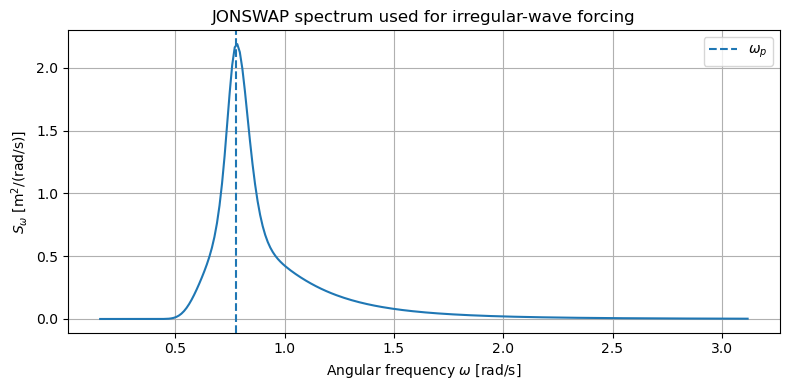

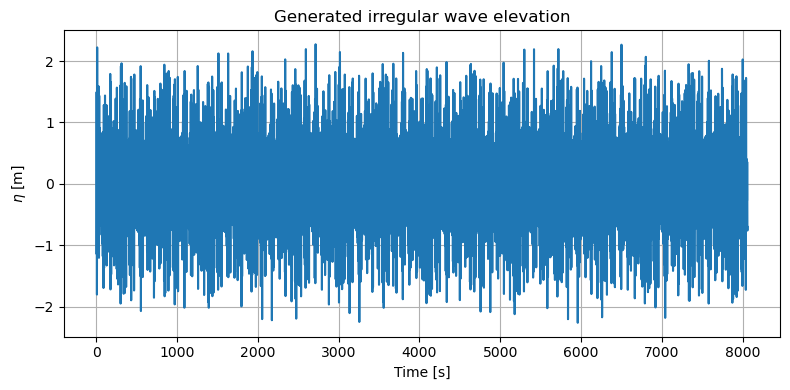

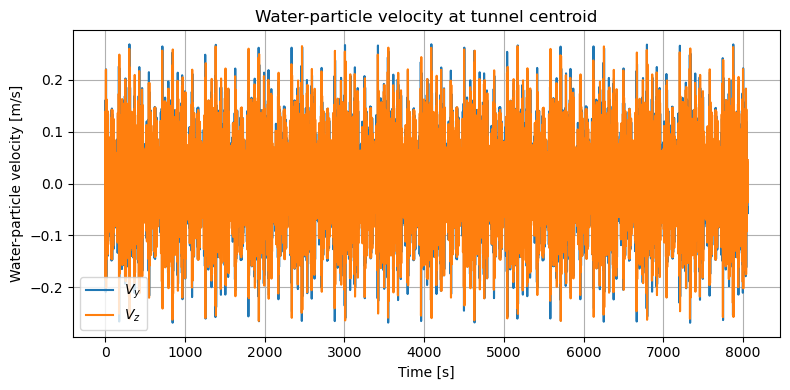

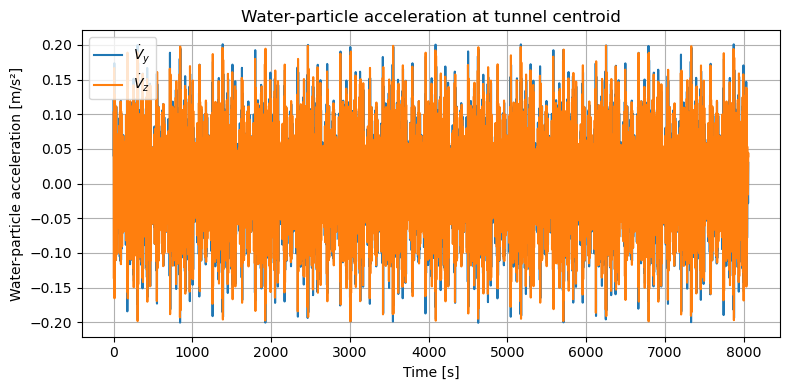

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(omega_components, S_omega)
plt.axvline(omega_p, linestyle="--", label=r"$\omega_p$")
plt.xlabel(r"Angular frequency $\omega$ [rad/s]")
plt.ylabel(r"$S_\omega$ [m$^2$/(rad/s)]")
plt.title("JONSWAP spectrum used for irregular-wave forcing")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(tspan, eta_t)
plt.xlabel("Time [s]")
plt.ylabel(r"$\eta$ [m]")
plt.title("Generated irregular wave elevation")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(tspan, V_y_t, label=r"$V_y$")
plt.plot(tspan, V_z_t, label=r"$V_z$")
plt.xlabel("Time [s]")
plt.ylabel("Water-particle velocity [m/s]")
plt.title("Water-particle velocity at tunnel centroid")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(tspan, Vdot_y_t, label=r"$\dot{V}_y$")
plt.plot(tspan, Vdot_z_t, label=r"$\dot{V}_z$")
plt.xlabel("Time [s]")
plt.ylabel("Water-particle acceleration [m/s²]")
plt.title("Water-particle acceleration at tunnel centroid")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Build JONSWAP water-particle velocity and acceleration vectors ────────
# Existing harmonic code used one complex Vdot_hat. For JONSWAP we instead
# construct the actual time history:
#     F(t) = Q_inertia * Vdot(t) + Q_drag * V(t)
# where Q_drag is the Lorentz-linearised drag/damping matrix.

mask_y = (DofsF % LDOF == 1)   # horizontal displacement v DOFs
mask_z = (DofsF % LDOF == 2)   # vertical displacement w DOFs

Q_inertia = Q_inertia_FF
Q_drag    = Q_drag_FF

n_time = len(tspan)
F_time = np.zeros((nDofsF, n_time), dtype=float)

# Chunked construction avoids storing full V(t) and Vdot(t) arrays for all time.
chunk_size = 500

for j0 in range(0, n_time, chunk_size):
    j1 = min(j0 + chunk_size, n_time)
    nt = j1 - j0

    V_chunk = np.zeros((nDofsF, nt), dtype=float)
    Vdot_chunk = np.zeros((nDofsF, nt), dtype=float)

    V_chunk[mask_y, :] = V_y_t[None, j0:j1]
    V_chunk[mask_z, :] = V_z_t[None, j0:j1]

    Vdot_chunk[mask_y, :] = Vdot_y_t[None, j0:j1]
    Vdot_chunk[mask_z, :] = Vdot_z_t[None, j0:j1]

    F_time[:, j0:j1] = (
        Q_inertia @ Vdot_chunk
        + Q_drag @ V_chunk
    )

print("F_time shape =", F_time.shape)

iy = np.where(mask_y)[0][0]
iz = np.where(mask_z)[0][0]


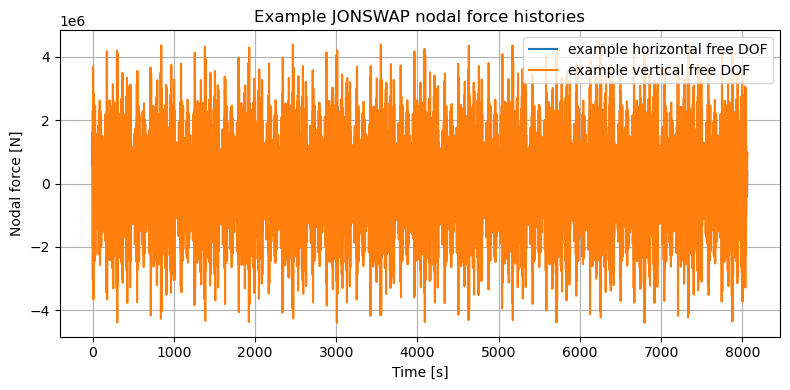

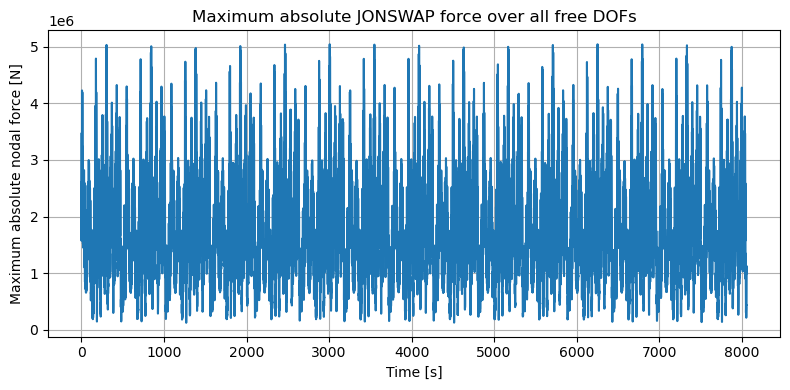

Max |F(t)| over all free DOFs and all time = 5.044e+06 N


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(tspan, F_time[iy, :], label="example horizontal free DOF")
plt.plot(tspan, F_time[iz, :], label="example vertical free DOF")
plt.xlabel("Time [s]")
plt.ylabel("Nodal force [N]")
plt.title("Example JONSWAP nodal force histories")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(tspan, np.max(np.abs(F_time), axis=0))
plt.xlabel("Time [s]")
plt.ylabel("Maximum absolute nodal force [N]")
plt.title("Maximum absolute JONSWAP force over all free DOFs")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Max |F(t)| over all free DOFs and all time = {np.max(np.abs(F_time)):.3e} N")

## Modal reduction

In [ ]:
mat = np.dot(np.linalg.inv(M_FF), K_FF)
w2, vr = np.linalg.eig(mat) #omega^2, eigenvectors
w = np.sqrt(w2.real)
f = w/2/np.pi               #natural frequencies
print(len(f))

idx = f.argsort()           #sort freqencies, vectors and modal shapes in descending order
f = f[idx]
vr = vr[:,idx]      
nMode = len(f)
ModalShape = np.zeros((nDof, nMode))
ModalShape[DofsF,:] = vr


6474


In [ ]:
print(f)

n_plot = 30

plt.figure(figsize=(8,4))
plt.plot(np.arange(1, n_plot+1), f[:n_plot], 'o-')
plt.xlabel('Mode number')
plt.ylabel('Natural frequency [Hz]')
plt.title('First natural frequencies')
plt.grid(True)
plt.tight_layout()
plt.show()

[2.05031111e-03 2.07586218e-03 2.13139284e-03 ... 2.79110297e+02
 2.79114631e+02 2.79117232e+02]


In [ ]:
# Mode selection based on excitation frequency
# In this cell find which modes we want to use for reduced model and replaces nMode with it
# (Do not use this cell if you want to find the full response)

f_cutoff = omega_max / (2 * np.pi)   # highest frequency in the spectrum
print(f_cutoff)

# Modes below cutoff frequency
freq_modes = np.where(f <= f_cutoff)[0]

if len(freq_modes) == 0:
    raise ValueError("No modes found below cutoff frequency.")

nMode_freq = freq_modes[-1] + 1

print(f"Frequency cutoff = {f_cutoff:.5f} Hz")
print(f"Modes below cutoff = {nMode_freq}")

nMode = nMode_freq

# full response check
# nMode = len(vr)

0.4962779156327543
Frequency cutoff = 0.49628 Hz
Modes below cutoff = 259


In [ ]:
# # Finding a_ray and b_ray for Rayleigh damping
# omega1 = w[0]      # rad/s
# omega2 = w[nMode]      # e.g. 5th mode

# zeta1 = 0.05
# zeta2 = 0.05

# A = np.array([
#     [1/(2*omega1), omega1/2],
#     [1/(2*omega2), omega2/2]
# ])
# rhs = np.array([zeta1, zeta2])
# a_ray, b_ray = np.linalg.solve(A, rhs)
# print(a_ray, b_ray)

In [ ]:
# Calculate modal quantities
PHI = vr[:,0:nMode]

Mm = np.zeros(nMode)
Km = np.zeros(nMode)
Cm = np.zeros(nMode)

ModalDampRatio = 0.05

# For now, structural damping added using Modal Damping Ratio. Very big displacements, prob. because added damping not included
# MDR 0.05 chosen, standard for reinforced concrete
for iMode in np.arange(0,nMode):
    # print('Computing Mode: ',iMode+1) # Starts at 0 off course
    Mm[iMode] = PHI[:,iMode].T @ M_FF @ PHI[:,iMode]
    Km[iMode] = PHI[:,iMode].T @ K_FF @ PHI[:,iMode]
    Cm[iMode] = 2*ModalDampRatio*np.sqrt(Mm[iMode]*Km[iMode])
    # print('Mm = ',Mm[iMode],', Km = ', Km[iMode],', Cm = ', Cm[iMode])

# # Rayleigh damping. a_ray and b_ray found in cell above. Leads to very small displacements (0.4 m), but crazy high response freq
# for iMode in np.arange(0,nMode):
#     # print('Computing Mode: ',iMode+1) # Starts at 0 off course
#     Mm[iMode] = PHI[:,iMode].T @ M_FF @ PHI[:,iMode]
#     Km[iMode] = PHI[:,iMode].T @ K_FF @ PHI[:,iMode]
#     Cm[iMode] = a_ray * Mm[iMode] + b_ray * Km[iMode]
    # print('Mm = ',Mm[iMode],', Km = ', Km[iMode],', Cm = ', Cm[iMode])

In [ ]:
# Effective mass participation criterion, change target to include more or less modes in nMode
target = 0.99       #0.999 at 1210 modes, 0.9999 around 2400
batch_size = 10

# Influence vectors
r_y = np.zeros(len(DofsF))
r_z = np.zeros(len(DofsF))

for iNode in range(nNode):
    global_v = iNode * LDOF + 1
    global_w = iNode * LDOF + 2
    if global_v in DofsF:
        r_y[np.where(DofsF == global_v)[0][0]] = 1.0
    if global_w in DofsF:
        r_z[np.where(DofsF == global_w)[0][0]] = 1.0

total_mass_y = r_y.T @ M_FF @ r_y
total_mass_z = r_z.T @ M_FF @ r_z

nMode_max = vr.shape[1]
cum_eff_y = 0.0
cum_eff_z = 0.0
eff_mass_y = []
eff_mass_z = []

i = 0
while i < nMode_max:
    i_end = min(i + batch_size, nMode_max)

    for j in range(i, i_end):
        phi = vr[:, j]
        modal_mass = phi.T @ M_FF @ phi
        Gamma_y = (phi.T @ M_FF @ r_y) / modal_mass
        Gamma_z = (phi.T @ M_FF @ r_z) / modal_mass
        eff_mass_y.append(Gamma_y**2 * modal_mass)
        eff_mass_z.append(Gamma_z**2 * modal_mass)

    cum_eff_y = sum(eff_mass_y) / total_mass_y
    cum_eff_z = sum(eff_mass_z) / total_mass_z
    i = i_end

    # print(f"Modes evaluated: {i:4d} | cum_y = {cum_eff_y:.6f} | cum_z = {cum_eff_z:.6f}")

    if cum_eff_y >= target and cum_eff_z >= target:
        break
else:
    print(f"Warning: target {target} not reached with all {nMode_max} modes.")

print(f"cum_y = {cum_eff_y:.6f} | cum_z = {cum_eff_z:.6f}")
nMode_mass = len(eff_mass_y)  # modes needed to meet target

# Only extend PHI, Mm, Km, Cm if mass criterion exceeds frequency cutoff
nMode_new = max(nMode_freq, nMode_mass)

if nMode_new > nMode:
    print(f"Extending modal quantities from {nMode} to {nMode_new} modes...")
    for iMode in range(nMode, nMode_new):
        phi = vr[:, iMode]
        modal_mass = phi.T @ M_FF @ phi
        Mm = np.append(Mm, modal_mass)
        Km = np.append(Km, phi.T @ K_FF @ phi)
        Cm = np.append(Cm, 2 * ModalDampRatio * np.sqrt(modal_mass * (phi.T @ K_FF @ phi))) # Modal damping
        # Cm = np.append(Cm, a_ray * modal_mass + b_ray * (phi.T @ K_FF @ phi))                     # Rayleigh damping
    PHI = vr[:, 0:nMode_new]

# nMode = nMode_new
print(f"Final nMode = {nMode}")

cum_y = 0.990554 | cum_z = 0.993392
Final nMode = 259


## Solving and post-processing

In [ ]:
# ── Precompute modal force time history from physical F_time ─────────────
# F_time has shape (nDofsF, n_time) — already built by groupmate's cell.
# Project onto modal basis: Fm_time[r, t] = PHI[:,r].T @ F_time[:, t]
# PHI is (nDofsF, nMode), F_time is (nDofsF, n_time) → result is (nMode, n_time)

Fm_time = PHI.T @ F_time      # shape (nMode, n_time)

# Interpolator so the ODE solver can query Fm at any t within tspan
Fm_interp = interp1d(
    tspan, Fm_time,
    axis=1,
    kind='linear',
    bounds_error=False,
    fill_value=(Fm_time[:, 0], Fm_time[:, -1]),
    assume_sorted=True
)

# ── Modal ODE ─────────────────────────────────────────────────────────────
q0 = np.zeros(2 * nMode)

def qdot(t, y):
    """
    Modal ODE: nMode uncoupled 2nd-order oscillators.
    State vector interleaved: y = [q0, qdot0, q1, qdot1, ...]
    """
    dydt = np.empty_like(y)
    fm = Fm_interp(t)          # shape (nMode,)
    for r in range(nMode):
        qr  = y[2*r]
        dqr = y[2*r + 1]
        dydt[2*r]     = dqr
        dydt[2*r + 1] = (fm[r] - Cm[r]*dqr - Km[r]*qr) / Mm[r]
    return dydt

# ── Solve ─────────────────────────────────────────────────────────────────
t_f_actual = tspan[-1]

sol = scpi.solve_ivp(
    fun    = qdot,
    t_span = [t_0, t_f_actual],
    y0     = q0,
    t_eval = tspan,
    method = 'DOP853',
    rtol   = 1e-3,
    atol   = 1e-6,
)

q_modal  = sol.y[0::2, :]    # shape (nMode, n_time)
qd_modal = sol.y[1::2, :]

# Back-project to physical free DOFs
x_phys = PHI @ q_modal       # shape (nDofsF, n_time)

MemoryError: Unable to allocate 3.89 GiB for an array with shape (6474, 80602) and data type float64

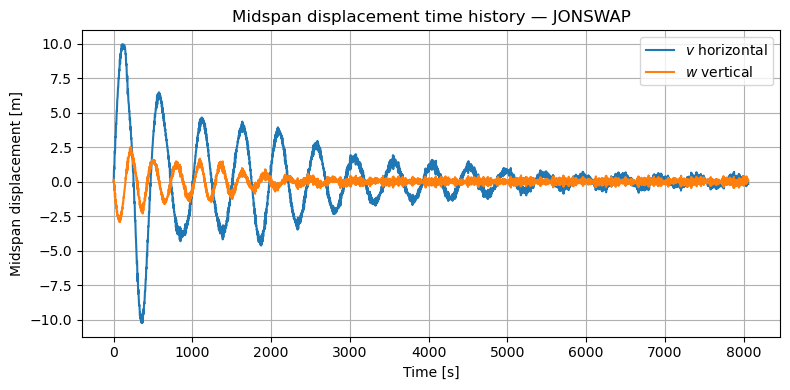

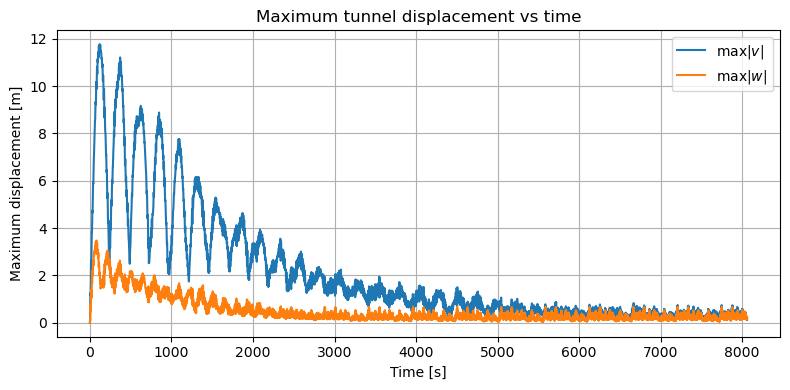

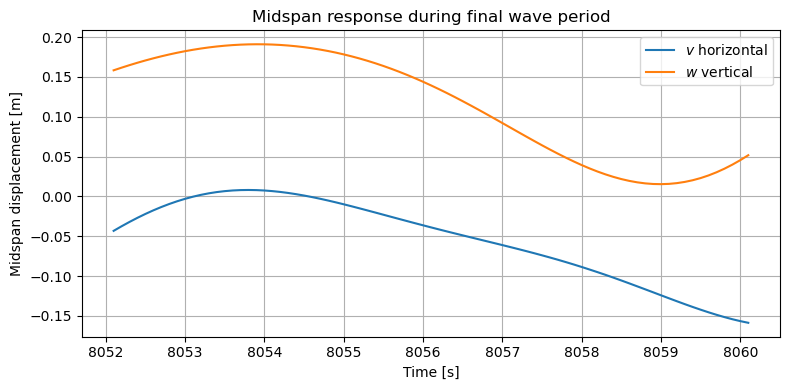

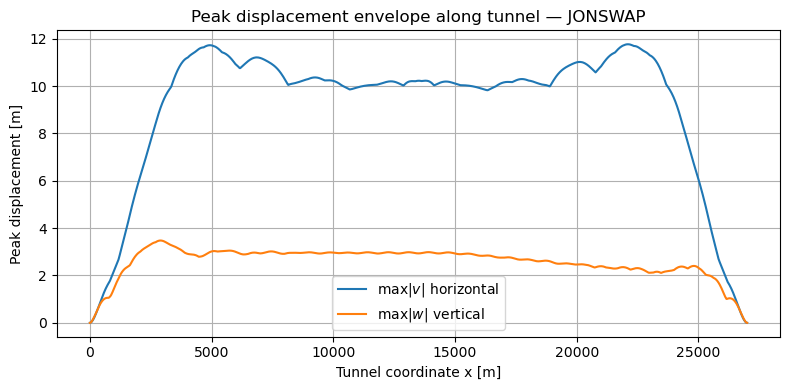

JONSWAP response statistics (midspan):
  Significant v (≈4σ): 9.336 m
  Significant w (≈4σ): 2.167 m
  Max |v| over all nodes: 11.771 m
  Max |w| over all nodes: 3.477 m
Total run time: 999.3 min


In [ ]:
# ── Reconstruct full physical displacement ────────────────────────────────
n_time = len(sol.t)
q_full_time = np.zeros((nDof, n_time))
q_full_time[DofsF, :] = x_phys

v_dofs = np.arange(1, nDof, LDOF)
w_dofs = np.arange(2, nDof, LDOF)

v_time_nodes = q_full_time[v_dofs, :]
w_time_nodes = q_full_time[w_dofs, :]

try:
    x_nodes = np.asarray(NodeC)[:, 0]
except:
    x_nodes = np.arange(len(v_dofs))

mid_node = len(v_dofs) // 2

# ── Plots ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(sol.t, v_time_nodes[mid_node, :], label=r'$v$ horizontal')
plt.plot(sol.t, w_time_nodes[mid_node, :], label=r'$w$ vertical')
plt.xlabel('Time [s]')
plt.ylabel('Midspan displacement [m]')
plt.title('Midspan displacement time history — JONSWAP')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 4))
plt.plot(sol.t, np.max(np.abs(v_time_nodes), axis=0), label=r'$\max|v|$')
plt.plot(sol.t, np.max(np.abs(w_time_nodes), axis=0), label=r'$\max|w|$')
plt.xlabel('Time [s]')
plt.ylabel('Maximum displacement [m]')
plt.title('Maximum tunnel displacement vs time')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

idx_last = sol.t >= (sol.t[-1] - 10*Tp)

plt.figure(figsize=(8, 4))
plt.plot(sol.t[idx_last], v_time_nodes[mid_node, idx_last], label=r'$v$ horizontal')
plt.plot(sol.t[idx_last], w_time_nodes[mid_node, idx_last], label=r'$w$ vertical')
plt.xlabel('Time [s]')
plt.ylabel('Midspan displacement [m]')
plt.title('Midspan response during final wave period')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ── Statistics (replaces single-frequency amplitude extraction) ───────────
v_sig = 4 * np.std(v_time_nodes[mid_node, :])
w_sig = 4 * np.std(w_time_nodes[mid_node, :])

v_max_envelope = np.max(np.abs(v_time_nodes), axis=1)   # peak per node
w_max_envelope = np.max(np.abs(w_time_nodes), axis=1)

plt.figure(figsize=(8, 4))
plt.plot(x_nodes, v_max_envelope, label=r'$\max|v|$ horizontal')
plt.plot(x_nodes, w_max_envelope, label=r'$\max|w|$ vertical')
plt.xlabel('Tunnel coordinate x [m]')
plt.ylabel('Peak displacement [m]')
plt.title('Peak displacement envelope along tunnel — JONSWAP')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

# ── Modal contribution plots ───────────
modal_rms = np.sqrt(np.mean(q_modal**2, axis=1))

plt.figure(figsize=(8,4))
plt.bar(np.arange(1, len(modal_rms)+1), modal_rms)
plt.xlabel('Mode number')
plt.ylabel('RMS modal coordinate')
plt.title('Relative modal contributions')
plt.grid(True)
plt.tight_layout()
plt.show()

modal_energy = np.sum(q_modal**2, axis=1)
modal_percent = 100 * modal_energy / np.sum(modal_energy)

plt.figure(figsize=(8,4))
plt.bar(np.arange(1, len(modal_percent)+1), modal_percent)
plt.xlabel('Mode number')
plt.ylabel('Contribution [%]')
plt.title('Modal energy contribution')
plt.grid(True)
plt.tight_layout()
plt.show()

print('JONSWAP response statistics (midspan):')
print(f'  Significant v (≈4σ): {v_sig:.3f} m')
print(f'  Significant w (≈4σ): {w_sig:.3f} m')
print(f'  Max |v| over all nodes: {np.max(np.abs(v_time_nodes)):.3f} m')
print(f'  Max |w| over all nodes: {np.max(np.abs(w_time_nodes)):.3f} m')

loop_EndTime = time.time()
print(f'Total run time: {(loop_EndTime - loop_StartTime)/60:.1f} min')

## Results ROM, 259 modes
JONSWAP response statistics (midspan): \
  Significant v (≈4σ): 9.336 m \
  Significant w (≈4σ): 2.167 m \
  Max |v| over all nodes: 11.771 m \
  Max |w| over all nodes: 3.477 m \
Total run time: 999.3 min 